# Homework 2: Probability Models

BEE 4850/5850

**Name**: Madeline Allen

**ID**: mca76

> **Due Date**
>
> Friday, 2/21/25, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practice developing and
working with probability models for data.

-   Problem 1 asks you to fit a sea-level rise model using normal
    residuals and to assess the validity of that assumption.
-   Problem 2 asks you to model the time series of hourly
    weather-related variability at a tide gauge using an autoregressive
    model.
-   Problem 3 asks you to use Poisson regression to predict salamander
    counts based on environmental data.
-   Problem 4 (only required for students in BEE 5850) asks you to look
    at the impact of the gender of hurricane names on deaths[1].

[1] Yes, seriously. Ish. Trust me, I know.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

I asked Chatgpt (OpenAI, 2025) "what are python equivalent packages to these julia packages" with the code block from original HW2; below is the result. The only two it recommended that I didn't use last time were scipy.optimize and random.

In [1]:
# Import packages:
import pandas as pd
import numpy as np 
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns 
import random  
import scipy.optimize as optimize
from scipy.stats import norm
from scipy.optimize import minimize

## Problems

### Scoring

-   Problem 1 is worth 7 points.
-   Problem 2 is worth 6 points.
-   Problem 3 is worth 7 points.
-   Problem 4 is worth 5 points.

### Problem 1

Consider the following sea-level rise model from [Grinsted et al
(2010)](https://doi.org/10.1007/s00382-008-0507-2), which models
sea-level rise based on a linear relationship between global mean
temperature and an “equilibrium” sea level:

$$\begin{align*}
\frac{dS}{dt} &= \frac{S_\text{eq} - S}{\tau} \\
S_\text{eq} &= aT + b,
\end{align*}
$$

where

-   $S(t)$ is the global mean sea level (in mm) at time $t$;
-   $\tau$ is the response time of sea level (in yrs);
-   $S_\text{eq}$ is the equilibrium sea-level (in mm) at temperature
    $T$ (in $^\circ$ C);
-   $a$ is the sensitivity of $S_\text{eq}$ to $T$ (in mm/$^\circ$ C);
-   $b$ is the intercept of $S_\text{eq}$, or the $S_\text{eq}$ when
    $T=0^\circ$ C (in mm).

**In this problem**:

-   Load the data from the `data/` folder and, following Grinsted et al
    (2010), normalize both datasets to the 1980-1999 mean (subtract that
    mean from the data).
    -   Global mean temperature data from the HadCRUT 5.0.2.0 dataset
        (<https://hadobs.metoffice.gov.uk/hadcrut5/data/HadCRUT.5.0.2.0/download.html>)
        can be found in
        `data/HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv`.
        This data is averaged over the Northern and Southern Hemispheres
        and over the whole year.
    -   Global mean sea level anomalies (relative to the 1990 mean
        global sea level) are in `data/CSIRO_Recons_gmsl_yr_2015.csv`,
        courtesy of CSIRO
        (<https://www.cmar.csiro.au/sealevel/sl_data_cmar.html>). The
        standard deviation of the estimate is also added for each year.
-   Write a function to simulate global mean sea levels under a set of
    model parameters after discretizing the equations above with a
    timestep of $\delta t = 1$ yr. You will need to subset the
    temperature data to the years where you also have sea-level data.
-   Fit the model under the assumption of Gaussian i.i.d. residuals
    (include both an uncertain model error term and the standard
    deviation of the observations in the probability model
    specification) by maximizing the likelihood. Report the parameter
    estimates. Note that you will need another parameter $S_0$ for the
    initial sea level. What can you conclude about the relationship
    between global mean temperature increases and global mean sea level
    rise rates?
-   How appropriate was the Gaussian i.i.d. probability model for the
    residuals? Use any needed quantitative or qualitative assessments of
    goodness of fit to justify your answer. If this was not an
    appropriate probability model, what would you change?

In [2]:
#  Load data
temp = pd.read_csv("data/HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv") 
sea = pd.read_csv("data/CSIRO_Recons_gmsl_yr_2015.csv") 

# Round down the time on sea_lev_anom for simplicity, since 1880.5 is the mean sea level in 1880, as noted in ed discussion post
sea['Time'] = sea['Time'].astype(int)

# normalize both datasets to the 1980-1999 mean
temp_mean = temp[(temp['Time']>=1980) & (temp['Time']<=1999)]['Anomaly (deg C)'].mean()
print('Mean temp anomaly from 1980-1999:', temp_mean)
sea_mean = sea[(sea['Time']>=1980) & (sea['Time']<=1999)]['GMSL (mm)'].mean()
print('Mean sea level anomaly from 1980-1999:', sea_mean)

# subtract mean from data:
temp['temp_anom_normalized'] = temp['Anomaly (deg C)'] - temp_mean
sea['GMSL_anom_normalized'] = sea['GMSL (mm)'] - sea_mean
# print(temp.head(10))
# print(sea.head(10))

# Figure out what years both datasets contain:
print('temp min year: ', temp['Time'].min())
print('temp max year: ', temp['Time'].max())
print('sea min year: ', sea['Time'].min())
print('sea max year: ', sea['Time'].max())

# we want 1880-2013; filter datasets:
temp_filt = temp[(temp['Time']>=1880)&(temp['Time']<=2013)].reset_index(drop=True)
sea_filt = sea[(sea['Time']>=1880)&(sea['Time']<=2013)].reset_index(drop=True)


Mean temp anomaly from 1980-1999: 0.24016621270000002
Mean sea level anomaly from 1980-1999: 0.375
temp min year:  1850
temp max year:  2023
sea min year:  1880
sea max year:  2013


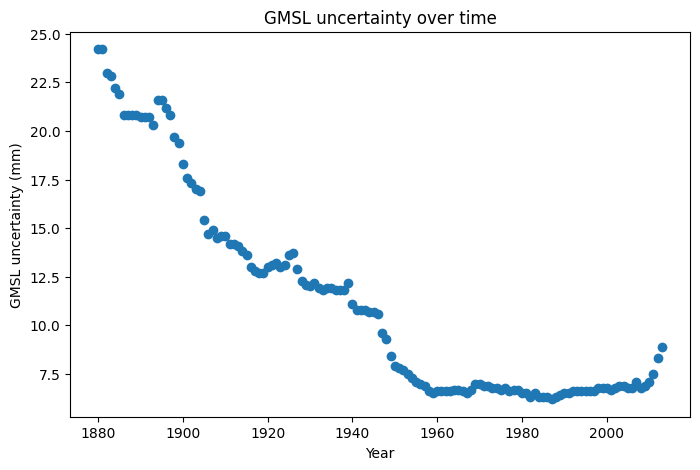

In [3]:
# Plot 
plt.figure(figsize=(8, 5))
plt.scatter(sea_filt['Time'], sea_filt["GMSL uncertainty (mm)"])
plt.xlabel("Year")
plt.ylabel("GMSL uncertainty (mm)")
plt.title("GMSL uncertainty over time")
plt.show()


As shown in the figure above, the GMSL uncertainty (standard deviation associated with each observation) decreases in time - as such, when developing the error portion of the model below, it makes sense to have the observational error vary in time (i.e., use this uncertainty term as the standard deviation directly, for each observation, rather than summarizing it as the mean and then using that as the standard deviation for the observational error - i.e., account for the changing observaitonal error over time, and let the discrepancy/model error encompass whatever error is left after that observational error is accounted for).

## Function to simulate global mean sea levels under a set of model parameters (discretized eqn):

The code below includes a function used to simulate global mean sea levels under a set of model parameters after discretizing the equations above with a timestep of $\delta t = 1$ yr/. First, I converted the code on the lecture slides that demonstrated the fitting of the eurler discretized equation using chatgpt (OpenAI, 2025); I copied and pasted that python code, and then modified it myself to work for this problem (i.e., any changes made from the python equivalent of course lecture code was done by me, not by chatgpt). 

In [4]:
# Function to simulate global mean sea levels under a set of model parameters (discretized eqn):
def sea_level_model(a, b, tau, S0, global_temp = temp_filt['temp_anom_normalized']):    
    dt = 1 # 1 year 
    T = global_temp
    S = np.zeros(len(T))
    S[0] = S0    
    for i in range(len(T) - 1):
        S[i+1] = S[i] + ((a * T[i] + b - S[i])/tau)*dt
    return S

In [5]:
# Gaussian iid; calculate the log likelihood (and make it negative so you can easily minimize it in order to find the max likelihood estimates)
def neg_log_likelihood(params, sea_level_data = sea_filt['GMSL_anom_normalized'], sea_level_error = sea_filt['GMSL uncertainty (mm)']):# , m=sea_level_model_wrap):
    # note - sigma here is standard deviation of the discrepancy term
    a, b, tau, S0, sigma = params 
    sea_level_sim = sea_level_model(a, b, tau, S0, global_temp = temp_filt['temp_anom_normalized'])
    # Assuming gaussian iid; and the error term is a combination of the model error (represented by sigma) 
    # and the observational error (standard deviation in the sea level measurements)
    # Note that here, the observational error is different for each observation, as discussed in the comment above
    ll = np.sum(norm.logpdf(sea_level_data, loc=sea_level_sim, scale=np.sqrt(sigma**2 + sea_level_error**2)))
    return -ll # return negative log likelihood

In [6]:
# define lower and upper bounds, and initial parameter estimations
lower = [-10000.0, -10000.0, 0.1, -10000.0, 0.0]
upper = [10000.0, 10000.0, 10000.0, 10000.0, 10.0]
p0 = [1.0, 1.0, 1.0, 1.0, 1.0]

result = minimize(neg_log_likelihood, p0, bounds=list(zip(lower, upper)))
θ_iid = result.x
a_hat, b_hat, tau_hat, S0_hat, sigma_hat = result.x

## Reporting parameter estimates - conclusions about key relationships:

In [7]:
print('The paramaeter estiatmes for a, b, tau, S0, sigma are: ', θ_iid)

The paramaeter estiatmes for a, b, tau, S0, sigma are:  [ 506.12982783  350.46904696  149.96404485 -157.22669652    0.        ]


Recall that the model above is a discretized version of the following, to predict sea level rise based on a linear relationship between global mean
temperature and an “equilibrium” sea level:

$$\begin{align*}
\frac{dS}{dt} &= \frac{S_\text{eq} - S}{\tau} \\
S_\text{eq} &= aT + b,
\end{align*}
$$

where

-   $S(t)$ is the global mean sea level (in mm) at time $t$;
-   $\tau$ is the response time of sea level (in yrs);
-   $S_\text{eq}$ is the equilibrium sea-level (in mm) at temperature
    $T$ (in $^\circ$ C);
-   $a$ is the sensitivity of $S_\text{eq}$ to $T$ (in mm/$^\circ$ C);
-   $b$ is the intercept of $S_\text{eq}$, or the $S_\text{eq}$ when
    $T=0^\circ$ C (in mm).

**Conclusions about the relationship between global mean temperature increases and global mean sea level rise rates:** 
- Examining the implications of the parameter estiamtes above, we see that:
- $a$ is the sensitivity of $S_\text{eq}$ to $T$, is roughly 506 mm/$^\circ$ C; **this is the parameter that is the most useful in interpreting the relationship between global mean temperature increases and global mean sea level rise rates - it's essentially saying that for every degree temperatuer increase, sea level will increase by roughly half a meter.**
- $b$ is 350 mm, meaning that $S_\text{eq}$ when $T=0^\circ$ C is 350 mm.
- $\tau$, which is the response time of sea level, is roughly 150 years. I.e., it takes the sea level 150 years to fully adjust to changes in temperature.
- **Interestingly, sigma is approximately zero, which implies that the maximum likelihood estimate of the standard deviation associated with the model error/ discrepancy term is zero - i.e., the observational error is large enough such that no additional error is attributed to the model error.** 


## Examining assumption of Gaussian i.i.d. residuals

 The model above was fit under the assumption of Gaussian i.i.d. residuals which include both a discrepancy term (i.e., model uncertainty) and an observational error term (i.e., the observational error in the sea level estimates, as reported by the standard deviation in the observational dataset). The parameter estimates that come from maximizing the likelihood of the function are printed above. Below, the assumption of Gaussian i.i.d. residuals is evaluated.

 I first converted the code from the lecture slides from julia to python using chatgpt (OpenAI, 2025); I copied and pasted that python code, and then modified it myself to work for this problem (i.e., any changes made from the python equivalent of course lecture code was done by me, not by chatgpt).

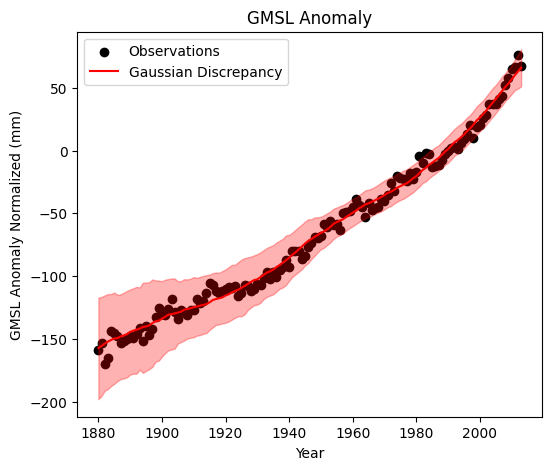

In [8]:
# Python equivalent from lecture slides produced via chatgpt (openai, 2025) - modified to use for this problem:
# num samples
n_samples = 10_000

# Simulate IID best fit
gmsl_iid = sea_level_model(a_hat, b_hat, tau_hat, S0_hat, global_temp = temp_filt['temp_anom_normalized'])  

# Simulate projections with discrepancy and errors
gmsl_iid_proj = np.zeros((n_samples, len(sea_filt["GMSL uncertainty (mm)"])))

for i in range(len(sea_filt["GMSL uncertainty (mm)"])):
    gmsl_iid_err = np.random.normal(0, np.sqrt(θ_iid[-1]**2 + sea_filt["GMSL uncertainty (mm)"][i]**2), n_samples)
    gmsl_iid_proj[:, i] = gmsl_iid[i] + gmsl_iid_err

# Calculate quantiles
gmsl_iid_q = np.quantile(gmsl_iid_proj, [0.05, 0.5, 0.95], axis=0)
# gmsl_iid_q = np.quantile(gmsl_iid_proj, [0.20, 0.5, 0.80], axis=0)

# Plot results
plt.figure(figsize=(6, 5))
plt.scatter(sea_filt['Time'], sea_filt['GMSL_anom_normalized'], color='black', label="Observations")
plt.plot(sea_filt['Time'], gmsl_iid_q[1, :], color='red', label="Gaussian Discrepancy")
plt.fill_between(sea_filt['Time'], gmsl_iid_q[0, :], gmsl_iid_q[2, :], color='red', alpha=0.3)
plt.xlabel("Year")
plt.ylabel("GMSL Anomaly Normalized (mm)")
plt.title("GMSL Anomaly")
plt.legend()
plt.show()


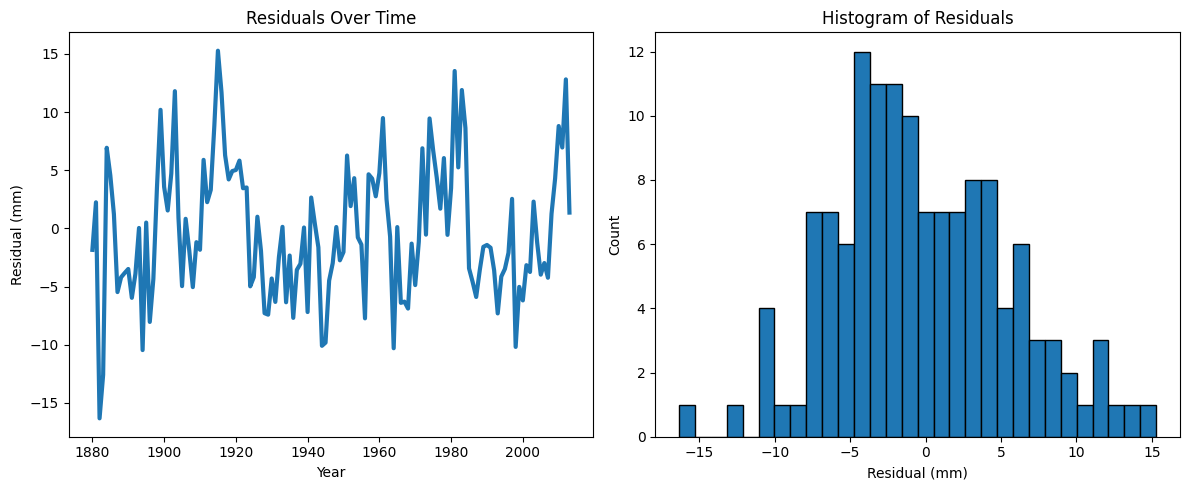

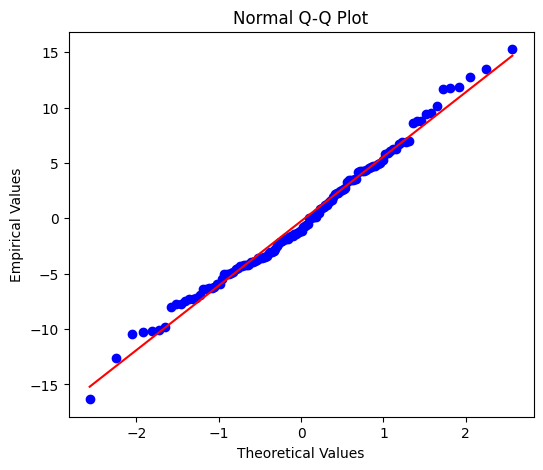

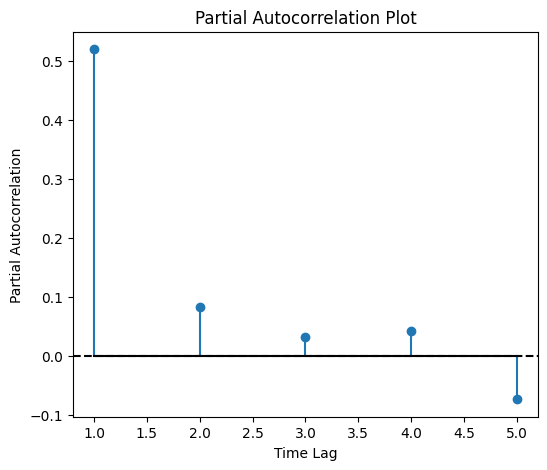

In [9]:
# Python equivalent from lecture slides produced via chatgpt (openai, 2025) - modified to use for this problem:
# Compute residuals
resids_homogauss = sea_filt['GMSL_anom_normalized'] - gmsl_iid

# Create figure and axes for plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # Side-by-side plots

# Plot residuals over time
axes[0].plot(sea_filt['Time'], resids_homogauss, linewidth=3)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Residual (mm)")
axes[0].set_title("Residuals Over Time")

# Plot histogram of residuals
axes[1].hist(resids_homogauss, bins=30, edgecolor="black")  # Adjust bins as needed
axes[1].set_xlabel("Residual (mm)")
axes[1].set_ylabel("Count")
axes[1].set_title("Histogram of Residuals")

# Display the plots
plt.tight_layout()
plt.show()

# Python equivalent from lecture slides produced via chatgpt (openai, 2025) - modified to use for this problem:
from statsmodels.tsa.stattools import pacf
# Q-Q Plot
fig, ax = plt.subplots(figsize=(6, 5))
stats.probplot(resids_homogauss, dist="norm", plot=ax)
ax.set_title("Normal Q-Q Plot")
ax.set_xlabel("Theoretical Values")
ax.set_ylabel("Empirical Values")
plt.show()

# Partial Autocorrelation Plot
lags = np.arange(1, 6)  # Equivalent to 1:5 in Julia
pacf_homogauss = pacf(resids_homogauss, nlags=5)[1:6]  # Exclude lag 0

fig, ax = plt.subplots(figsize=(6, 5))
ax.stem(lags, pacf_homogauss, linefmt="C0-", markerfmt="C0o", basefmt="k-")
ax.axhline(0, color="black", linestyle="dashed")  # Horizontal dashed line at 0
ax.set_xlabel("Time Lag")
ax.set_ylabel("Partial Autocorrelation")
ax.set_title("Partial Autocorrelation Plot")

plt.show()


**Conclusions re: assumption of Gaussian iids residuals:** Based on the diagnostic plots shown above - I would conclude that the residuals do appear to be roughly normally distributed, however they are not independent, and thus the condition of i.i.d. (independent and identically distributed) is not satisfied. The reason I connclude that the residuals are roughly normally distributed is based on the histogram (where the residuals range from roughly -15 to 15 and appear approximately normal, though potentially slighlty right-skewed), and the Q-Q plot shows that the empirically calculated quantiles roughly aline with the theoretical quantiles (the points would fall ~exactly along the red 1:1 line if the residuals were perfectly normal; here we see some deviation from this 1:1 line but likely a sufficiently small amount such that violation of the normality assumption will not impact inference or prediction dramatically). **However, the plot of residuals over time indicate that they are likely not indepepndent of one another** (e.g., if the previous timestep had a positive residual, it visually seems more likely that the following residual will be positive rather than negative, and vice versa with negative residuals) - **this is confirmed in the partial autocorrelation plot** which reveals a partial autocorrelation of more than 0.5 at a lag time of 1 (which represents a **moderately strong autocorrelation**; though there is negligible autocorrelation for longer lag times). As such - I would conclude that since the assumption of independent (not correlated) residuals is violated, this is not an appropriate probabilty model. A key change that I would make, would be incorporating this lag one autocorrelation in the discrepancy term. To do so, I would essentially turn the discrepancy term into an AR(1) probability model. I.e., if in the current model formulation, the discrepancy term is normally distributed with mean zero and standard deviation sigma (as found via MLE above): $\delta_t \sim N(0, \sigma^2)$, I would instead make the discrepancy term equal to $\delta_t = \delta_{t-1} + \omega_t$, where $\omega_t \sim N(0, \sigma^2)$. By changing this model formulation and again use MLE to obtain estimates of the parameters (now, with the addition of $\rho$). This type of AR(1) error model formulation is essentially what the next problem utilizes.

### Problem 2

Tide gauge data is complicated to analyze because it is influenced by
different harmonic processes (such as the linear cycle). In this
problem, we will develop a model for this data using [NOAA data from the
Sewell’s Point tide
gauge](https://tidesandcurrents.noaa.gov/waterlevels.html?id=8638610)
outside of Norfolk, VA from `data/norfolk-hourly-surge-2015.csv`. This
is hourly data (in m) from 2015 and includes both the observed data
(`Verified (m)`) and the tide level predicted by NOAA’s sinusoidal model
for periodic variability, such as tides and other seasonal cycles
(`Predicted (m)`).

**In this problem**:

-   Load the data file. Take the difference between the observations and
    the sinusoidal predictions to obtain the tide level which could be
    attributed to weather-related variability (since for one year
    sea-level rise and other factors are unlikely to matter). Plot this
    data.
-   Develop an autoregressive (AR) model for the weather-related
    variability in the Norfolk tide gauge. Make sure to include your
    logic or exploratory analysis used in determining the model
    specification.
-   Use your model to simulate 1,000 realizations of hourly tide gauge
    observations by adding simulations from your AR model back to the
    predicted sinusoidal trend. What is the distribution of the maximum
    tide level? How does this compare to the observed value?

In [10]:
#  Load data - surge, hourly data (in m)
surge = pd.read_csv("data/norfolk-hourly-surge-2015.csv") 
# Combine date and time columns (I'm not positive if this is actually necessary, but I thought if
# I only plotted a variable against Date then datapoints would be stacked on top of each other)
surge['datetime'] = pd.to_datetime(surge['Date'] + ' ' + surge['Time (GMT)'])
print(surge.head(5))


         Date Time (GMT)  Predicted (m) Preliminary (m)  Verified (m)  \
0  2015/01/01      00:00          0.480               -         0.616   
1  2015/01/01      01:00          0.325               -         0.432   
2  2015/01/01      02:00          0.145               -         0.242   
3  2015/01/01      03:00         -0.009               -         0.084   
4  2015/01/01      04:00         -0.099               -        -0.006   

             datetime  
0 2015-01-01 00:00:00  
1 2015-01-01 01:00:00  
2 2015-01-01 02:00:00  
3 2015-01-01 03:00:00  
4 2015-01-01 04:00:00  


## Exploratory analysis for AR model creation:

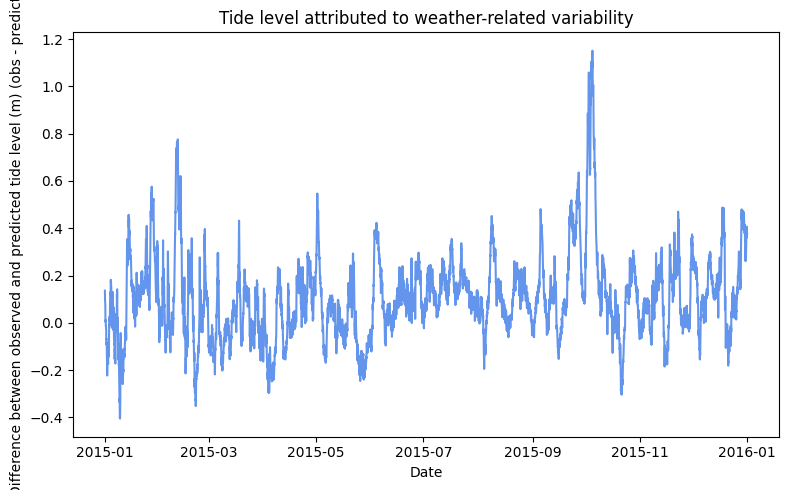

In [11]:
# Take difference between the observations and predictions 
# to obtain the tide level which could be attributed to weather-related variability 
surge['weather_variability'] = surge['Verified (m)'] - surge['Predicted (m)']

# Plot:
plt.figure(figsize=(8,5)) 
plt.plot(surge['datetime'],surge['weather_variability'], color='cornflowerblue')#, label='No Cheat')#, alpha = 0.8)
# Add labels
plt.xlabel('Date')
plt.ylabel('Difference between observed and predicted tide level (m) (obs - predicted)')
plt.title('Tide level attributed to weather-related variability')
plt.tight_layout()
plt.show()

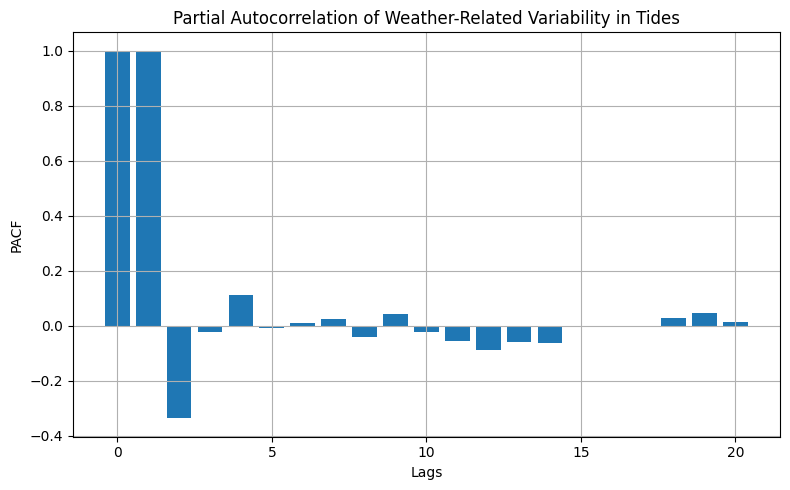

In [12]:
# Calculate PACF using statsmodels pacf function
# Note - I used chatgpt to figure out what the appropriate packages to use here; I asked 
# "how to compute and plot partial autocorrelation in python" and only used the lines of code that read in
# the packages correctly because I already had the plotting code from matplotlib documentation that used statsmodels functions.
# also note that by default this statsmodels package uses "ywadjusted” for the method - which is 
# "Yule-Walker with sample-size adjustment in denominator for acovf" 
# (statsmodels, 2024)
from statsmodels.tsa.stattools import pacf
from statsmodels.graphics.tsaplots import plot_pacf
pacf_values = pacf(surge['weather_variability'], nlags=20, method='ywadjusted') # ols-adjusted #ywadjusted


# Plot PACF
plt.figure(figsize=(8, 5))
plt.bar(range(len(pacf_values)), pacf_values)
# plot_pacf(pacf_values)
plt.title('Partial Autocorrelation of Weather-Related Variability in Tides')
plt.xlabel('Lags')
plt.ylabel('PACF')
plt.grid(True)
plt.tight_layout()
plt.show()

**Logic/explanation of AR model formulation:** 

Examining the raw timeseries of tide level attributed to weather, it appears to me that there is autocorrelation, but it is difficult to tell visually what lag times would be important to incorporate, so I plotted the autocorrelations.

After plotting the initial autocorrelation plot (not shown), I realized that since I was using autocorrelation instead of partial autocorrelation, I was seeing the effects that were noted in class lecture - i.e., that by only computing autocorrelation (using synthetically created data that only had a lag-1 dependence), we can still see evidence of autocorrelation between lag times beyond 1 lag. As done in lecture - in order to isolate zeta(i) independent of zeta(i-k), we can use **partial autocorrelation**, as done above. Note that the statsmodel package I uses a "Yule-Walker with sample-size adjustment in denominator for acovf" method to determine the partial autocorrelation (statsmodels, 2024); I used this method, and also tried the adjusted OLS method which did not result in any noticeable differences; for a more thorough analysis I would examine whether a different method of calculating the partial autocorrelation would be more appropriate for this use case (but here, just used the default method - adjusted Yule-Walker). **The results of the partial autocorrelation shown in the figure above show that there is a very strong autocorrelation in the first lag time (almost 1) and essentially no autocorrelation after lag 1. As such, I chose to use an AR(1) model.**

## AR(1) Model Formulation:

To code the AR model, I first converted the code on the AR(1) related lecture slides using chatgpt (OpenAI, 2025); I copied and pasted that python code, and then modified it myself to work for this problem (i.e., any changes made from the python equivalent of course lecture code was done by me, not by chatgpt).

In [13]:
# Python equivalent from lecture slides produced via chatgpt (openai, 2025) - modified to use for this problem:
from scipy.stats import norm, multivariate_normal
from scipy.stats import norm
from scipy.optimize import minimize

def ar1_loglik_whitened(theta, dat):
    """
    Compute the log-likelihood of an AR(1) process assuming whitened errors.
    
    Parameters:
        theta: tuple (rho, sigma) - AR(1) coefficient and noise standard deviation.
        dat: array-like - Time series data.
        
    Returns:
        Log-likelihood value.
    """
    rho, sigma = theta
    T = len(dat)
    ll = 0  # Initialize log-likelihood counter
    
    for i in range(T):
        if i == 0:
            ll += norm.logpdf(dat[i], loc=0, scale=np.sqrt(sigma**2 / (1 - rho**2)))
        else:
            ll += norm.logpdf(dat[i], loc=rho * dat[i-1], scale=sigma)
    
    return ll

def ar1_loglik_joint(theta, dat):
    """
    Compute the log-likelihood of an AR(1) process using the full covariance structure.
    
    Parameters:
        theta: tuple (rho, sigma) - AR(1) coefficient and noise standard deviation.
        dat: array-like - Time series data.
        
    Returns:
        Log-likelihood value.
    """
    rho, sigma = theta
    T = len(dat)
    
    # Construct the AR(1) covariance matrix
    H = np.abs(np.subtract.outer(np.arange(1, T+1), np.arange(1, T+1)))
    P = rho**H  # Element-wise exponentiation
    Sigma = (sigma**2 / (1 - rho**2)) * P
    
    # Compute the log-likelihood
    ll = multivariate_normal.logpdf(dat, mean=np.zeros(T), cov=Sigma)
    
    return ll

In [14]:
# build AR(1) model for weather-related variability in tides:
# Define optimization bounds and initial values
bounds = [(-0.9999, 0.9999), (0.0001, 100)]
init = [0.6, 0.3]

# Optimize using the whitened likelihood
result_whitened = minimize(lambda theta: -ar1_loglik_whitened(theta, surge['weather_variability']), init, bounds=bounds)
theta_wn_mle = result_whitened.x
print("MLE estimates for rho and sigma:", theta_wn_mle)

MLE estimates for rho and sigma: [0.99563917 0.01966356]


## Produce simulations:

In [15]:
# Use model to simulate 1,000 realizations of hourly tide gauge observations by adding simulations from your AR model back to the predicted sinusoidal trend
# AR(1) process parameters
rho = theta_wn_mle[0]
sigma =theta_wn_mle[1]
T = len(surge) #length of timeseries

max_tide_level = []

n_sim = 1000

# Simulate synthetic AR(1) series
for sim in range(n_sim):
    weather_tide_sim = np.zeros(T)
    for t in range(T):
        if t == 0:
            weather_tide_sim[t] = np.random.normal(0, np.sqrt(sigma**2 / (1 - rho**2)))
        else:
            weather_tide_sim[t] = np.random.normal(rho * weather_tide_sim[t-1], sigma)
    predicted = weather_tide_sim + surge['Predicted (m)']
    max_tide_level.append(np.max(predicted))


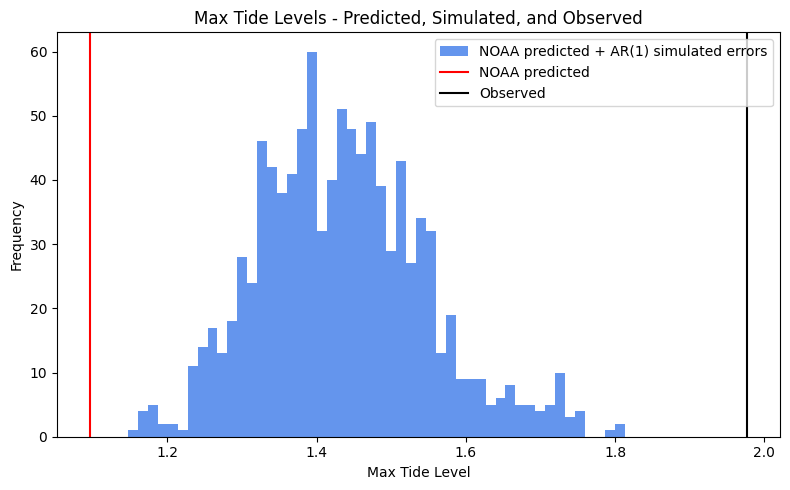

In [16]:
# Plot the simulated time series max tide levels:
plt.figure(figsize=(8, 5))
plt.hist(max_tide_level, bins = 50, color = 'cornflowerblue', label = 'NOAA predicted + AR(1) simulated errors')
plt.axvline(x=np.max(surge['Predicted (m)']), color = 'red', label='NOAA predicted')
plt.axvline(x=np.max(surge['Verified (m)']), color = 'black', label='Observed')
plt.xlabel("Max Tide Level")
plt.ylabel("Frequency")
plt.legend()
plt.title(fr"Max Tide Levels - Predicted, Simulated, and Observed")
plt.tight_layout()
plt.show()

 **INTERPRETATION:** The figure above shows the max tide level from 1,000 realizations of hourly tide gauge observations (obtained via adding 1,000 simulations of error from my AR(1) model to the NOAA predicted sinusoidal trend). The distribution of the maximum simulated tide level (blue bar plot above) appears to be a slightly right skewed normal distribution, and contains simulated max tide levels that are all greater than the original NOAA predicted simualted max tide level (which is not surprising, given that we are essentially adding error/noise onto a sinusoidal trend, which would result in some peaks having higher points than they previously did without the error imposed on them). However, comparing this distribution of max tide level with the observed value (black line), shows that all (or almost all; depends on initial random seed) of the simulated peaks are still lower than the actual observed max tide. This could be for a number of reasons - the most obvious of which, is that our simple AR(1) error model still does not capture all of the weather-related variability that causes the observed values to be different than the NOAA simulated sinusoidal trend (i.e., there is still variation in the data that is not explained by our model). Additionally, the results highlighted in the figure above are specifically looking at an extreme (the max tide level over the entire observational history that we're using) - it is not at all surprising to me that our model, which was not designed with accuracy of capturing extremes in mind, does not capture these extremes. It is likely you would want to create a different model (likely one that has some theory related to extreme values) in order to model the max tide. Additionally, you would likely want actual information about the weather in this given area, and use that to inform the model you're using to capture the difference between the simualted sinusoidal trend and the observed.

## Problem 3

The file `data/salamanders.csv` contains counts of salamanders from 47
different plots of the same area in California, as well as the
percentage of ground cover and age of the forest in the plot. You would
like to see if you can use these data to predict the salamander counts
with a Poisson regression.

**In this problem**:

-   Load the data. You may need to standardize the predictors as they
    are much larger than the counts.
-   Fit a Poisson regression model for salamander counts using the
    percentage of ground cover.
-   Plot the expected counts and 90% prediction intervals from your
    model. How well does the model predict the observed counts? In what
    ways does it do a good or bad job?
-   Can you improve the model by including forest age? Why do you think
    this helps or does not help with prediction?

## Load data and standardize predictors:

In [17]:
# Note - I asked chatgpt (openai, 2024) how to read in a csv that used semi colon as a delimiter (because this one loaded incorrectly due to that fact); based on its answer I added
# delimiter=";" to the code below.
sal = pd.read_csv("data/salamanders.csv", delimiter=";") 
print(sal.head(5))

   SITE  SALAMAN  PCTCOVER  FORESTAGE
0     1       13        85        316
1     2       11        86         88
2     3       11        90        548
3     4        9        88         64
4     5        8        89         43


In [18]:
# Standardize predictors
sal['PCTCOVER_scale'] = (sal['PCTCOVER'] - sal['PCTCOVER'].mean())/sal['PCTCOVER'].std()
sal['FORESTAGE_scale'] = (sal['FORESTAGE'] - sal['FORESTAGE'].mean())/sal['FORESTAGE'].std()

In [19]:
# # Plot:
# plt.figure(figsize=(8,5)) 
# plt.scatter(sal['PCTCOVER'], sal['SALAMAN'])
# # Add labels
# plt.xlabel('Percent Forest Cover')
# plt.ylabel('Salamanders Count')
# plt.title('Salamanders Count Based on Percent Forest Cover')
# plt.tight_layout()
# plt.show()

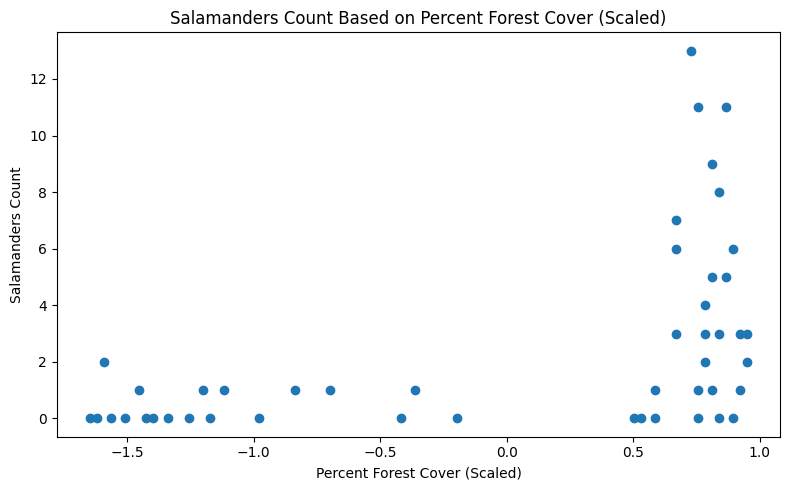

In [20]:
# Plot:
plt.figure(figsize=(8,5)) 
plt.scatter(sal['PCTCOVER_scale'], sal['SALAMAN'])
# Add labels
plt.xlabel('Percent Forest Cover (Scaled)')
plt.ylabel('Salamanders Count')
plt.title('Salamanders Count Based on Percent Forest Cover (Scaled)')
plt.tight_layout()
plt.show()

## Develop and fit Poisson model to predict salamander count based on forest cover:

The structure of my poisson model is:

$y_i \sim Poisson(\lambda_i)$

$f(\lambda_i) = beta_0 + beta_1 * PCTCOVER$

$\lambda_i = f^{-1} (beta_0 + beta_1 * PCTCOVER)$

And for this Poisson model, I think it makes sense to use the log link function (converting all real numbers that come out of the $beta_0 + beta_1 * PCTCOVER$ into only postive rate constant values).

So my model would be:

$y_i \sim Poisson(\lambda_i)$ where $\lambda_i = e\^{}(beta_0 + beta_1 * PCTCOVER)$

Note that in the above, I've kept it labeled as "PCTCOVER" but we're actually using a standardized version of that. 

To beging coding this, I first converted the code on the lecture slides on probability models from Julia to Python using chatgpt (OpenAI, 2025); I copied and pasted that python code, and then modified it myself to work for this problem (i.e., any changes made from the python equivalent of course lecture code was done by me, not by chatgpt).


Note that the way I chose the lower and upper bounds below is as follows: I know that my average count of salamanders is 2.46, meaning my funciton e^(β0 + β1 * pct_cover) should result in something vaguely in the ballpark of 2.46; meaning β0 + β1 * pct_cover is somewhere around ln(2.46) = 0.9034. Since I've already centered and scaled my variables, I certainly don't need lower and upper bounds of -100 and 100; I reduced them to -10 and 10 knowing that this is still very vague.

In [21]:
# Fit poisson regression salamander counts ~ Poisson(rate dependent on percent ground cover)
from scipy.stats import poisson
from scipy.optimize import minimize

# Define the model function using scipy's Poisson logpmf
def salamander_model(params, pct_cover, sal_count):
    β0, β1 = params
    λ = np.exp(β0 + β1 * pct_cover)  # Compute λ for each observation
    loglik = np.sum(poisson.logpmf(sal_count, λ))  # Compute log-likelihood
    return loglik

# Bounds and initial values
lb = [-10.0, -10.0]
ub = [10.0, 10.0]
init = [0.0, 0.0]

# Optimization (maximize log-likelihood, so minimize negative log-likelihood)
optim_out = minimize(lambda θ: -salamander_model(θ, pct_cover = sal['PCTCOVER_scale'], sal_count=sal['SALAMAN']), init, bounds=list(zip(lb, ub)))

# Extract MLE estimates
θ_mle = optim_out.x
β0_hat, β1_hat = θ_mle
print('Estimate of β0_hat: ',np.round(β0_hat, 2), 'Estimate of β1_hat: ', np.round(β1_hat, 2))

# Compute predicted lambda values
λ_hat = np.exp(β0_hat + β1_hat * sal['PCTCOVER_scale'])
sal['est_lambda_hat'] = λ_hat

# Compute 90% prediction intervals (5th and 95th percentiles of the Poisson distribution)
sal['lower_bound'] = poisson.ppf(0.05, λ_hat)
sal['upper_bound'] = poisson.ppf(0.95, λ_hat)

Estimate of β0_hat:  0.43 Estimate of β1_hat:  1.16


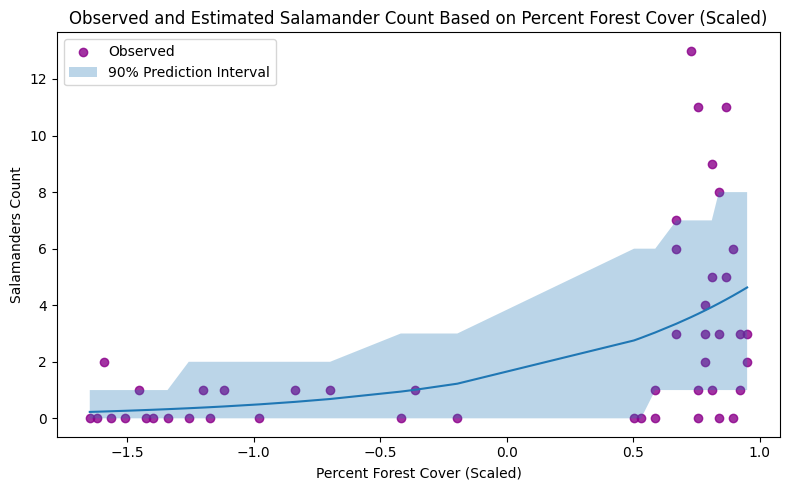

In [22]:
# Plot:
plt.figure(figsize=(8,5)) 
plt.scatter(sal['PCTCOVER_scale'], sal['SALAMAN'], label = 'Observed', color = 'darkmagenta', alpha = 0.8)
# plot 90% prediction intervals using the stored sal['lower_bound'] and sal['upper_bound']
sorted_df = sal.sort_values('PCTCOVER_scale')
plt.plot(sorted_df['PCTCOVER_scale'], sorted_df['est_lambda_hat'])
plt.fill_between(sorted_df['PCTCOVER_scale'], sorted_df['lower_bound'], sorted_df['upper_bound'], alpha= 0.3, label = '90% Prediction Interval')

# Add labels
plt.xlabel('Percent Forest Cover (Scaled)')
plt.ylabel('Salamanders Count')
plt.title('Observed and Estimated Salamander Count Based on Percent Forest Cover (Scaled)')
plt.legend()
plt.tight_layout()
plt.show()

Note - interpretation of this model is provided at the end of this question.

## Poisson model that includes forest age:

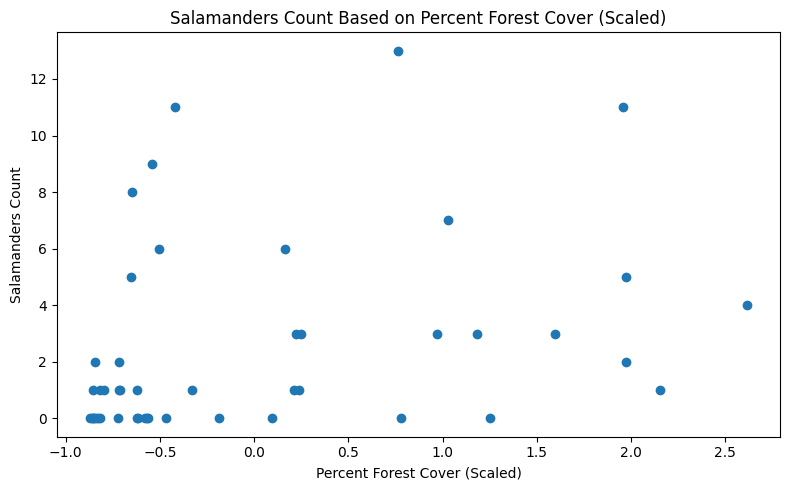

In [23]:
# Plot:
plt.figure(figsize=(8,5)) 
plt.scatter(sal['FORESTAGE_scale'], sal['SALAMAN'])
# Add labels
plt.xlabel('Percent Forest Cover (Scaled)')
plt.ylabel('Salamanders Count')
plt.title('Salamanders Count Based on Percent Forest Cover (Scaled)')
plt.tight_layout()
plt.show()

Right away, I would guess that this predictor won't be as helpful because visually there doesn't seem to be a very clear relationship between the two - but we'll see!

In [24]:
# Fit poisson regression salamander counts ~ Poisson(rate dependent on percent ground cover)
from scipy.stats import poisson
from scipy.optimize import minimize

# Define the model function using scipy's Poisson logpmf
def salamander_model_age(params, pct_cover, forest_age, sal_count):
    β0, β1, β2 = params
    λ = np.exp(β0 + β1 * pct_cover+ β2* forest_age)  # Compute λ for each observation
    loglik = np.sum(poisson.logpmf(sal_count, λ))  # Compute log-likelihood
    return loglik

# Bounds and initial values
lb = [-10.0, -10.0, -10.0]
ub = [10.0, 10.0, 10.0]
init = [0.0, 0.0, 0.0]

# Optimization (maximize log-likelihood, so minimize negative log-likelihood)
optim_out = minimize(lambda θ: -salamander_model_age(θ, pct_cover = sal['PCTCOVER_scale'], forest_age = sal['FORESTAGE_scale'], sal_count=sal['SALAMAN']), init, bounds=list(zip(lb, ub)))

# Extract MLE estimates
θ_mle_age = optim_out.x
β0_hat_age, β1_hat_age, β2_hat_age = θ_mle_age
print('Estimate of β0_hat: ',np.round(β0_hat_age, 2), 'Estimate of β1_hat: ', np.round(β1_hat_age, 2), 'Estimate of β2_hat: ', np.round(β2_hat_age, 2))

# Compute predicted lambda values
λ_hat_age = np.exp(β0_hat_age + β1_hat_age * sal['PCTCOVER_scale']+ β2_hat_age * sal['FORESTAGE_scale'])
sal['est_lambda_hat_age'] = λ_hat_age

# Compute 90% prediction intervals (5th and 95th percentiles of the Poisson distribution)
sal['lower_bound_age'] = poisson.ppf(0.05, λ_hat_age)
sal['upper_bound_age'] = poisson.ppf(0.95, λ_hat_age)


Estimate of β0_hat:  0.43 Estimate of β1_hat:  1.16 Estimate of β2_hat:  -0.0


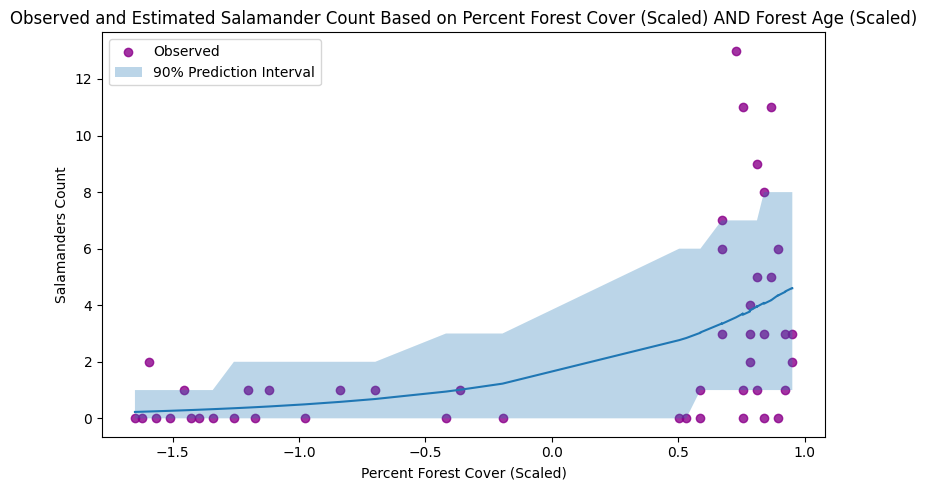

In [25]:
# Plot:
plt.figure(figsize=(8,5)) 
plt.scatter(sal['PCTCOVER_scale'], sal['SALAMAN'], label = 'Observed', color = 'darkmagenta', alpha = 0.8)
# plot 90% prediction intervals using the stored sal['lower_bound'] and sal['upper_bound']
sorted_df2 = sal.sort_values('PCTCOVER_scale')
plt.plot(sorted_df2['PCTCOVER_scale'], sorted_df2['est_lambda_hat_age'])
plt.fill_between(sorted_df2['PCTCOVER_scale'], sorted_df2['lower_bound_age'], sorted_df2['upper_bound_age'], alpha= 0.3, label = '90% Prediction Interval')


# Add labels
plt.xlabel('Percent Forest Cover (Scaled)')
plt.ylabel('Salamanders Count')
plt.title('Observed and Estimated Salamander Count Based on Percent Forest Cover (Scaled) AND Forest Age (Scaled)')
plt.legend()
plt.tight_layout()
plt.show()

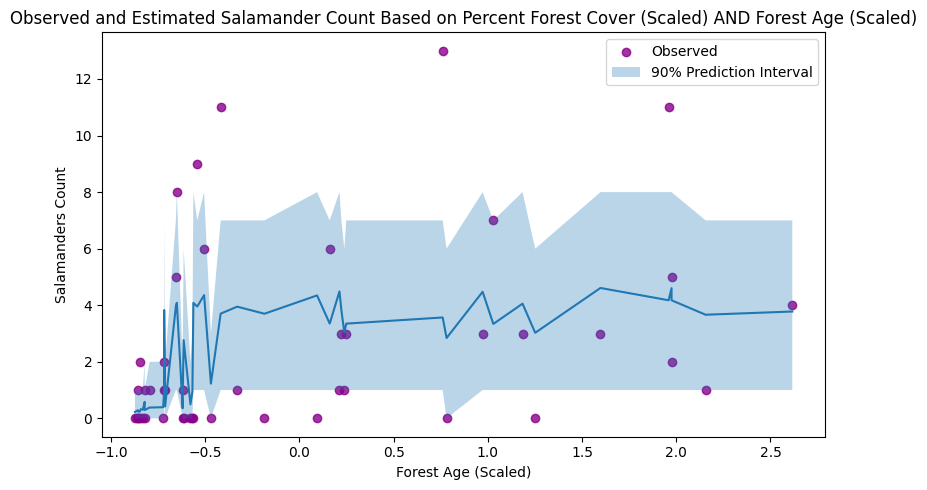

In [26]:
# Plot:
plt.figure(figsize=(8,5)) 
plt.scatter(sal['FORESTAGE_scale'], sal['SALAMAN'], label = 'Observed', color = 'darkmagenta', alpha = 0.8)
# plot 90% prediction intervals using the stored sal['lower_bound'] and sal['upper_bound']
sorted_df3 = sal.sort_values('FORESTAGE_scale')
plt.plot(sorted_df3['FORESTAGE_scale'], sorted_df3['est_lambda_hat_age'])
plt.fill_between(sorted_df3['FORESTAGE_scale'], sorted_df3['lower_bound_age'], sorted_df3['upper_bound_age'], alpha= 0.3, label = '90% Prediction Interval')


# Add labels
plt.xlabel('Forest Age (Scaled)')
plt.ylabel('Salamanders Count')
plt.title('Observed and Estimated Salamander Count Based on Percent Forest Cover (Scaled) AND Forest Age (Scaled)')
plt.legend()
plt.tight_layout()
plt.show()

Response below is for the following quesitons: How well does the model predict the observed counts? In what ways does it do a good or bad job? Can you improve the model by including forest age? Why do you think this helps or does not help with prediction?

**Interpretation of both Poisson models:**

**The poisson model that includes only scaled percent forest cover did not predict the observed counts very well.** One thing it did well, was to predict lower salamander counts for plots of land with lower percent forest cover, and larger counts for plots of land with higher forest cover (which we would anticipate, just based on the scatter plot of observed values). However, the 90% prediction interval frequently did not encompass zero (and there were several counts of zero for a very wide range of plot forest coverage types) and frequently the 90% prediction interval did not capture 90% of the data - this is particularly noticeable for the higher forest coverage plot range. I believe that a key issue with this model is that our data is overdispersed - i.e., the variance of salamander counts is larger than the mean, so a poisson distribution (where mean = variance) is not able to accurately capture the range of data we see. 

**The poisson model that includes BOTH scaled percent forest cover and scaled forest age also did not predict the observed counts very well, and from what I see - produces no clear improvement over the model with just percent forest cover.** As noted above, when you examine the original scatter plot that examines the number of salamanders vs. the forest age (scaled), there is no clear relationship (i.e., older forests do not appear to have larger salamander counts or vice versa). When I add in scaled forest age as a predictor to the Poisson regression, the coefficient assigned to this variable is very small (-0.00408389) meaning that in the maximum likelihood estimation of parameters, the forest age predictor receives very little weight (i.e., since the coefficient is very small, changes in forest age produce very little difference in the expected rate of the associated poisson distribution, and thus have very little impact on the predicted salamander count). When you visually compare the estimated counts with 90% prediction intervals for the resulting model, it looks almost exactly the same as the one from the original model (unsurprisingly).

### Problem 4

<span style="color:red;">GRADED FOR 5850 STUDENTS ONLY</span>

In 2014, [a paper was published in a prestigious
journal](https://www.pnas.org/doi/10.1073/pnas.1402786111) which claimed
that hurricanes with more feminine names are deadlier than hurricanes
with more masculine names because people take warnings about
female-named hurricanes less seriously[1]. The file
`data/Hurricanes.csv` contains the original data used in this analysis.
While we won’t replicate the specific analysis in this paper, let’s use
the data to look at this hypothesis.

**In this problem**:

-   One might interpret the hypothesis to claim that the impact of the
    name is strengthened by the the more powerful. A measure of
    hurricane strength is its minimum pressure (`min_pressure` in the
    dataset). Fit a model that predicts deaths (‘deaths’) using the
    femininity of the name (`femininity`) and minimum pressure (you may
    need to standardize the pressure).
-   Interpret the results by generating counterfactual simulations for
    hurricanes with the most feminine and masculine name scores. Plot
    the expected values and 90% prediction intervals from these two sets
    of simulations and compare with the observed storm deaths. Where
    does the model do well or not well? Does the effect size of the
    gender of the name seem plausible?
-   Conclude with a summary of your conclusions about the impact of the
    gender of a hurricane’s name on deaths. How might you change the
    approach in this problem to keep exploring this hypothesis, if at
    all?

[1] This paper has become a bit of a joke among statisticians, but let’s
take the hypothesis seriously for this problem’s sake.

### Load and standardize data; initial data exploration

In [27]:
#read in data; examine: 
hur = pd.read_csv('data/Hurricanes.csv', delimiter=";")
# standardize pressure:
hur['min_pressure_scaled'] = (hur['min_pressure'] - hur['min_pressure'].mean())/hur['min_pressure'].std()
print(hur.head(5))

       name  year  deaths  category  min_pressure  damage_norm  female  \
0      Easy  1950       2         3           960         1590       1   
1      King  1950       4         3           955         5350       0   
2      Able  1952       3         1           985          150       0   
3   Barbara  1953       1         1           987           58       1   
4  Florence  1953       0         1           985           15       1   

   femininity  min_pressure_scaled  
0     6.77778            -0.257695  
1     1.38889            -0.519951  
2     3.83333             1.053585  
3     9.83333             1.158488  
4     8.33333             1.053585  


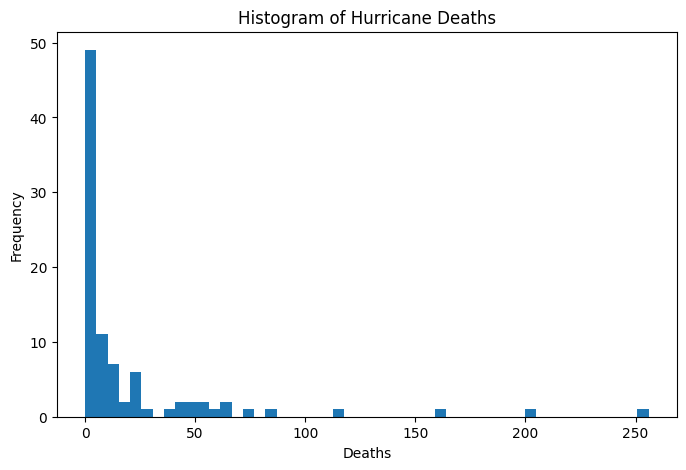

In [28]:
# Plot hist
plt.figure(figsize=(8, 5))
plt.hist(hur['deaths'], bins = 50)
plt.xlabel("Deaths")
plt.ylabel("Frequency")
plt.title("Histogram of Hurricane Deaths")
plt.show()

In [29]:
# Examine mean and variance:
mean_deaths = hur['deaths'].mean()
var_deaths = hur['deaths'].var()
# sd_deaths = hur['deaths'].std()
print(f'The average number of deaths is {round(mean_deaths,2)}, and the variance in the number of deaths is {round(var_deaths,2)}.')

The average number of deaths is 20.65, and the variance in the number of deaths is 1673.15.


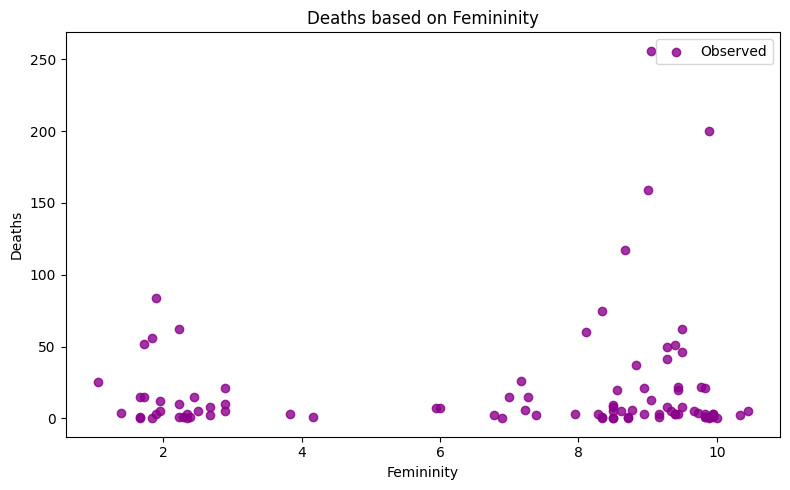

In [30]:
# Plot:
plt.figure(figsize=(8,5)) 
plt.scatter(hur['femininity'], hur['deaths'], label = 'Observed', color = 'darkmagenta', alpha = 0.8)
# Add labels
plt.xlabel('Femininity')
plt.ylabel('Deaths')
plt.title('Deaths based on Femininity')
plt.legend()
plt.tight_layout()
plt.show()

Just based on this histogram - I think overdispersion will be a problem for a Poisson regression (i.e., caused by a combination of a couple very large deaths and a large number of zero deaths, resulting in a variance that is larger than the mean). The calculations of mean and variance of deaths in the dataset confirm this. However, since the model needs to result in count value estiamtes of deaths based on predictors, I am still selecting a poisson regression, though if I had more time I would investigate whether a zero inflated poisson regression or a negative binomial does a better job of capturing the variability in the data.

### Fit Poisson model: deaths = $f$(femininity, pressure)

In [31]:
# Fit model: deaths = f(femininity, pressure)

# Fit poisson regression deaths ~ Poisson(rate dependent on femininity and pressure)
from scipy.stats import poisson
from scipy.optimize import minimize

# Define the model function using scipy's Poisson logpmf
def poisson_deaths(params, fem, pressure, deaths):
    β0, β1, β2 = params
    λ = np.exp(β0 + β1 * fem+ β2* pressure)  # Compute λ for each observation
    loglik = np.sum(poisson.logpmf(deaths, λ))  # Compute log-likelihood
    return loglik

# Bounds and initial values
lb = [-10.0, -10.0, -10.0]
ub = [10.0, 10.0, 10.0]
init = [0.0, 0.0, 0.0]

# Optimization (maximize log-likelihood, so minimize negative log-likelihood)
optim_out = minimize(lambda θ: -poisson_deaths(θ, fem = hur['femininity'], pressure = hur['min_pressure_scaled'], deaths=hur['deaths']), init, bounds=list(zip(lb, ub)))

# Extract MLE estimates
θ_mle = optim_out.x
β0_hat, β1_hat, β2_hat = θ_mle
print('Estimate of intercept β0_hat: ',np.round(β0_hat, 2), '  Estimate of femininity coefficient β1_hat: ', np.round(β1_hat, 2), '  Estimate of pressure coefficient β2_hat: ', np.round(β2_hat, 2))

# Compute predicted lambda values
λ_hat = np.exp(β0_hat + β1_hat * hur['femininity']+ β2_hat * hur['min_pressure_scaled'])
hur['est_lambda_hat'] = λ_hat

# Compute 90% prediction intervals (5th and 95th percentiles of the Poisson distribution)
hur['lower_bound'] = poisson.ppf(0.05, λ_hat)
hur['upper_bound'] = poisson.ppf(0.95, λ_hat)

Estimate of intercept β0_hat:  2.3   Estimate of femininity coefficient β1_hat:  0.06   Estimate of pressure coefficient β2_hat:  -0.72


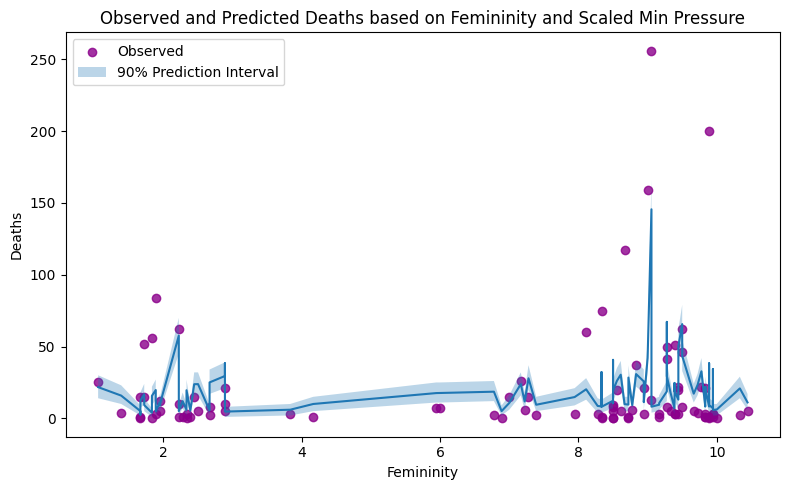

In [32]:
# Plot:
plt.figure(figsize=(8,5)) 
plt.scatter(hur['femininity'], hur['deaths'], label = 'Observed', color = 'darkmagenta', alpha = 0.8)

hur_sort = hur.sort_values('femininity')
plt.plot(hur_sort['femininity'], hur_sort['est_lambda_hat'])
plt.fill_between(hur_sort['femininity'], hur_sort['lower_bound'], hur_sort['upper_bound'], alpha= 0.3, label = '90% Prediction Interval')

# Add labels
plt.xlabel('Femininity')
plt.ylabel('Deaths')
# plt.ylim(0,100)
plt.title('Observed and Predicted Deaths based on Femininity and Scaled Min Pressure')
plt.legend()
plt.tight_layout()
plt.show()

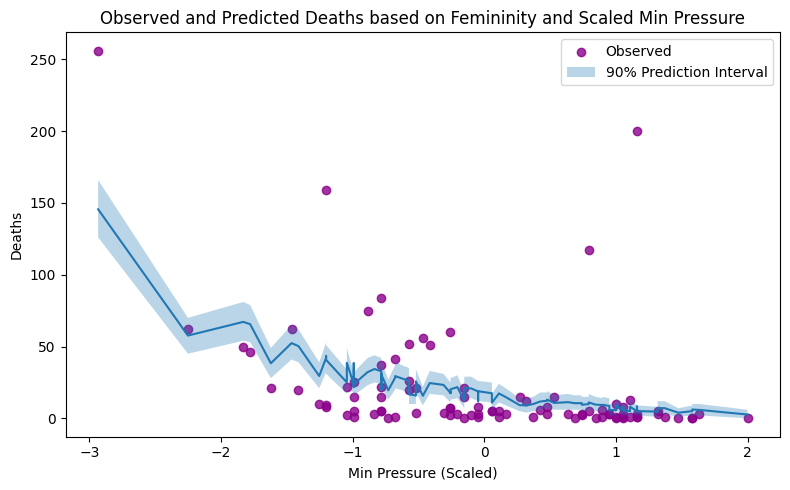

In [33]:
# Plot:
plt.figure(figsize=(8,5)) 
plt.scatter(hur['min_pressure_scaled'], hur['deaths'], label = 'Observed', color = 'darkmagenta', alpha = 0.8)

hur_sort2 = hur.sort_values('min_pressure_scaled')
plt.plot(hur_sort2['min_pressure_scaled'], hur_sort2['est_lambda_hat'])
plt.fill_between(hur_sort2['min_pressure_scaled'], hur_sort2['lower_bound'], hur_sort2['upper_bound'], alpha= 0.3, label = '90% Prediction Interval')


# Add labels
plt.xlabel('Min Pressure (Scaled)')
plt.ylabel('Deaths')
plt.title('Observed and Predicted Deaths based on Femininity and Scaled Min Pressure')
plt.legend()
plt.tight_layout()
plt.show()

Note - main interpretation of above results is at the end of this question

### Counterfactual:

In [34]:
# Create lambda hat w/ appropriate 90% bounds if femininity was always highest or lowest score 
most_fem = hur['femininity'].max()
least_fem= hur['femininity'].min()

# most feminine:
λ_hat_high_fem = np.exp(β0_hat + β1_hat * most_fem + β2_hat * hur['min_pressure_scaled'])
hur['est_lambda_hat_high_fem'] = λ_hat_high_fem
# Compute 90% prediction intervals (5th and 95th percentiles of the Poisson distribution)
hur['lower_bound_high_fem'] = poisson.ppf(0.05, λ_hat_high_fem)
hur['upper_bound_high_fem'] = poisson.ppf(0.95, λ_hat_high_fem)

# least feminine:
λ_hat_low_fem = np.exp(β0_hat + β1_hat * least_fem + β2_hat * hur['min_pressure_scaled'])
hur['est_lambda_hat_low_fem'] = λ_hat_low_fem
# Compute 90% prediction intervals (5th and 95th percentiles of the Poisson distribution)
hur['lower_bound_low_fem'] = poisson.ppf(0.05, λ_hat_low_fem)
hur['upper_bound_low_fem'] = poisson.ppf(0.95, λ_hat_low_fem)


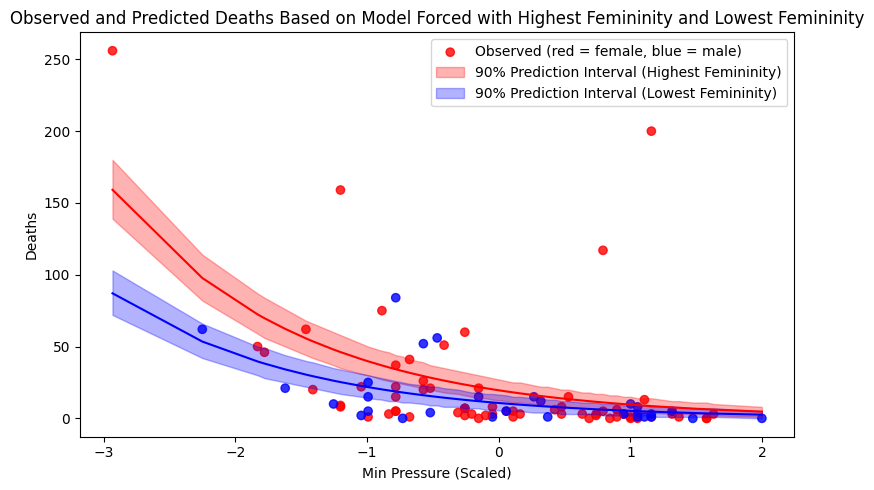

In [35]:
# Plot:
plt.figure(figsize=(8,5)) 

# make scatter plot points red if hur['female'] is 1, and blue if it's 0
# Note - I used chatgpt (OpenAI, 2025) for the following one line of code to figure out how to make the points red and blue; I asked it 
# how to adapt the line to follow the comment above - i.e., "make scatter plot points red if hur['female'] is 1, and blue if it's 0"
plt.scatter(hur['min_pressure_scaled'], hur['deaths'],  c=hur['female'].map({1: 'red', 0: 'blue'}), alpha = 0.8, label = 'Observed (red = female, blue = male)')

hur_sort2 = hur.sort_values('min_pressure_scaled')
plt.plot(hur_sort2['min_pressure_scaled'], hur_sort2['est_lambda_hat_high_fem'], color = 'red')
plt.fill_between(hur_sort2['min_pressure_scaled'], hur_sort2['lower_bound_high_fem'], hur_sort2['upper_bound_high_fem'], alpha= 0.3, label = '90% Prediction Interval (Highest Femininity)', color = 'red')

plt.plot(hur_sort2['min_pressure_scaled'], hur_sort2['est_lambda_hat_low_fem'], color = 'blue')
plt.fill_between(hur_sort2['min_pressure_scaled'], hur_sort2['lower_bound_low_fem'], hur_sort2['upper_bound_low_fem'], alpha= 0.3, label = '90% Prediction Interval (Lowest Femininity)', color = 'blue')


# Add labels
plt.xlabel('Min Pressure (Scaled)')
plt.ylabel('Deaths')
plt.title('Observed and Predicted Deaths Based on Model Forced with Highest Femininity and Lowest Femininity')
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
# side note:
percent_hurricanes_female = np.sum(hur['female'])/len(hur['female']) * 100
print(f'Out of the {len(hur)} hurricanes in this dataset, {round(percent_hurricanes_female,2)}% of them are female.')

Out of the 92 hurricanes in this dataset, 67.39% of them are female.


### Interpretation:

The initial plots that show the 90% prediction interval (prior to examining the counterfactual) show that a Poisson regression model that uses femininity and scaled minimum pressure overall does a very poor job at predicting the deaths that result from a given hurricane, as indicated by the fact that the 90% prediction interval in these plots excludes the majority of the data. **When we examine the counterfactual example in the plot above** (i.e., examining the range of possible scaled minimum pressures, while forcing the model with either the most feminine or least feminine scores), we notice several things; to note a few:
1) the model, forced with the most feminine score and the entire range of scaled minimum pressure, fails to capture the hurricanes that resulted in the most deaths (which were in fact female for the top 4, but our Poisson model is not able to produce estiamted death counts nearly as high as these for their given minimum pressures). 
2) There are a wide range of observations that are not captured by either model (or the space in between themm, which represents intermediate values of feminininty used in this model framework); including many death counts that are relatively close to zero. 
3) Of these lower death counts (e.g., hurricanes with death counts less than 20 or so), many of the hurricanes associated with them have female names (which goes against the overarching hyptohesis that hurricanes with feminine names have larger death counts).

**Where the model does well:**
- One of the only things the model does well (from what I can see) is that generally speaking, lower minimum pressure is associated with higher deaths, which is what I would have expected based on what I know of the physics of hurricanes, and is somewhat apparent in the data (though notably, the top handful of hurricanes that produced the most deaths have a relatively wide range of scaled minimum pressure, so this overarching statement doesn't appear to hold for the extremes - or more likely, there are several other factors not considered that would explain this - as discussed below).


**Where the model does poorly:**
- Honestly this model seems pretty awful to me. I think it's even more obvious how poorly it does in the plots that show the original model 90% confidence interval (not the counter factual) - where you can see the majority of the points are not contained in the prediction interval - i.e., the given Poisson model does not capture the observed data well. 

**Plausibility of the effect size of the gender of the name:**
- I do not think that the effect size of the gender of the name of the hurricane on the resulting predicted death counts seems plausible. E.g., for a very low pressure hurricane (such as -3 for scaled minimum pressure), this model predicts that if the hurricane has a very feminine name instead of a very masculine name, there would be roughly two times as many deaths. This just seems ridiculous to me. Discussed more below - options for evaluating this effect size more.

**Summary of conclusions:**
- Key conclusions from above: the model created to produce estiamtes of death count based on femininity of hurricane name, and scaled minimum pressure, does a poor job at capturing the observed data, and is overall not a good model. Beyond this clear serious shortcoming (model's inability to predict observed data well), I think that the resulting effect size of the gender of the name of the hurricane is incredibly unrealistic. I could potentially believe that people may have some kinds of biases that cause them to take a female-named hurricane less seriously than a male-named hurricane, but I do not think it makes sense to suggest that the death count would double for a very feminine hurricane compared to very masculine hurricane.
- One of my biggest qualms with this approach, is that no efforts were made to take into account several critical factors in determining death count, including: how many people were in the path of the hurricane as it made landfall, what evacuation measures were taken, how accurately the hurricane followed its forecasted paths, and how much time the general populace in these areas had to prepare for the hurricane. Choosing just one of these to examine: one way this model could be improved, would be to obtain data for the total population in the hurricane's path, and normalize the death count by this. This would at least help you account for the basic fact that if two hurricanes of the same strength were to hit areas with orders of magnitude different populations, you would expect the hurricane hitting the larger population to likely produce more deaths (this goes back to risk = likelihood x exposure, discussed in previous homework assignment). Realistically, for this model to have findings that I would even remotely believe, all of the factors listed in this bullet would need to be addressed; and after they are all included, then examine the impact of gender of a hurricane name on death count.
- Another key issue, is that there is no attempt to account for the fact that out of the 92 hurricanes in this dataset, roughly 67% of them are female, and thus just by chance - the subset of hurricanes with the highest death counts (e.g., top 5) is likely to contain more female names, simply based on the fact that more hurricanes get female names (according to this dataset). One way this could be explored in more depth, would be to essentially do a similar simulation experiment as we did with the beer/water mosquito quesiton on HW1: shuffle the 'female' column of the dataset and compute the difference between average deaths for male hurricanes and female hurrcanes, repeat this 10,000 times, and see where the observed difference in death count falls among this simulated distribution of difference between those two groups results (i.e., evaluate the null hypothesis that the gender of the hurricane has no impact on death count - i.e., they come from the same underlying population). 

## References

OpenAI. (2025). ChatGPT (Feb 12 version) [Large language model]. https://chatgpt.com/


Statsmodels. (2025). statsmodels.tsa.stattools.pacf documentation. https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.pacf.html 